<a href="https://colab.research.google.com/github/dionatrafk/model_evaluation/blob/master/ARIMA_exec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Auto Regressive Integrated Moving Average (ARIMA)

In [0]:
#Importar datasets
!git clone https://github.com/dionatrafk/model_evaluation

**Execution options: **default 60 minute predictions.

**Copy a row of hyperparameters and paste into row 2 of the next cell.**

'trace1.csv', 0, 1, 2 \
'trace5.csv', 2, 0, 1 \
'trace10.csv', 0, 1, 1 \
'trace15.csv', 0, 2, 1 \
'trace20.csv', 1, 0, 2 \
'trace25.csv', 4, 0, 1 \
'trace30.csv', 2, 0, 2 \
'trace35.csv', 4, 0, 1 \
'trace40.csv', 8, 0, 1 \
'trace45.csv', 2, 0, 2 \
'trace50.csv', 2, 0, 1 \
'trace55.csv', 10, 0, 2 \
'trace60.csv', 2, 1, 2 \

In [8]:
#define hyperparameters
filename, p, d, q = 'trace60.csv', 2, 1, 2

path = './http_requests_nasa/'
filename = path + filename

2 1 2


/var/folders/6r/_412zf1x3q34nyf8f2mf_rw80000gp/T/ipykernel_49937/3342832570.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset = read_csv(filename, header=0, parse_dates=[0], index_col=0)


Timer:  0:00:05.814259
R2: 0.84, Testscore: 276937.16 MSE (526.25 RMSE)


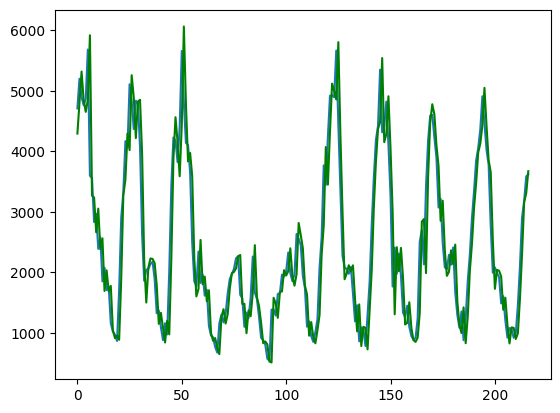

In [16]:
from pandas import read_csv
from matplotlib import pyplot
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt
import numpy as np
import sys, os
import datetime

#perc = float(sys.argv[5])
print(p, d, q)
#read the csv file
dataset = read_csv(filename, header=0, parse_dates=[0], index_col=0)

# split into train and test sets
X = dataset.values
X = X.astype('float32')
size = int(len(X) * 0.67)
train, test = X[0:size], X[size:len(X)]
series = [x for x in train]
predictions = list()

training_size = len(train)

#test with less samples	
#size = int(training_size * (perc /100))
#series = series[size:training_size:]
timer = start = datetime.datetime.now() 
# walk-forward validation
#print 'current, prediction'
for t in range(len(test)):
  model = ARIMA(series, order=(p,d,q))
  model_fit = model.fit()
  output = model_fit.forecast()

  yhat = output[0]
  predictions.append(yhat)
  current = test[t]
  series.append(current)
 
  #print('%.2f, %.2f' % (current,yhat))

# evaluate forecasts

print("Timer: ", datetime.datetime.now() - timer)
score = mean_squared_error(test, predictions)
r2 = r2_score(test, predictions)
print('R2: %.2f, Testscore: %.2f MSE (%.2f RMSE)' %(r2,score, math.sqrt(score)))

#plot the execution
pyplot.plot(test)
pyplot.plot(predictions, color='green')
pyplot.show()
